In [3]:
#Read in the museum csv file
import pandas as pd
import matplotlib.pyplot as plt



In [5]:
# Create DataFrame from csv file
museum_df = pd.read_csv('museums.csv', dtype=str)

In [6]:
museum_df.head()

,Museum ID,Museum Name,Legal Name,Alternate Name,Museum Type,Institution Name,Street Address (Administrative Location),City (Administrative Location),State (Administrative Location),Zip Code (Administrative Location),...,Latitude,Longitude,Locale Code (NCES),County Code (FIPS),State Code (FIPS),Region Code (AAM),Employer ID Number,Tax Period,Income,Revenue
0,8400200098,ALASKA AVIATION HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,NaN,HISTORY MUSEUM,NaN,4721 AIRCRAFT DR,ANCHORAGE,AK,99502,...,61.17925,-149.97254,1,20,2,6,920071852,201312,602912,550236
1,8400200117,ALASKA BOTANICAL GARDEN,ALASKA BOTANICAL GARDEN INC,NaN,"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",NaN,4601 CAMPBELL AIRSTRIP RD,ANCHORAGE,AK,99507,...,61.1689,-149.76708,4,20,2,6,920115504,201312,1379576,1323742
2,8400200153,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,NaN,SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,NaN,9711 KENAI SPUR HWY,KENAI,AK,99611,...,60.56149,-151.21598,3,122,2,6,921761906,201312,740030,729080
3,8400200143,ALASKA EDUCATORS HISTORICAL SOCIETY,ALASKA EDUCATORS HISTORICAL SOCIETY,NaN,HISTORIC PRESERVATION,NaN,214 BIRCH STREET,KENAI,AK,99611,...,60.5628,-151.26597,3,122,2,6,920165178,201412,0,0
4,8400200027,ALASKA HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,NaN,HISTORY MUSEUM,NaN,301 W NORTHERN LIGHTS BLVD,ANCHORAGE,AK,99503,...,61.17925,-149.97254,1,20,2,6,920071852,201312,602912,550236


MOST museums per capita:  VT — 17.9 per 100K
LEAST museums per capita: UT — 1.6 per 100K



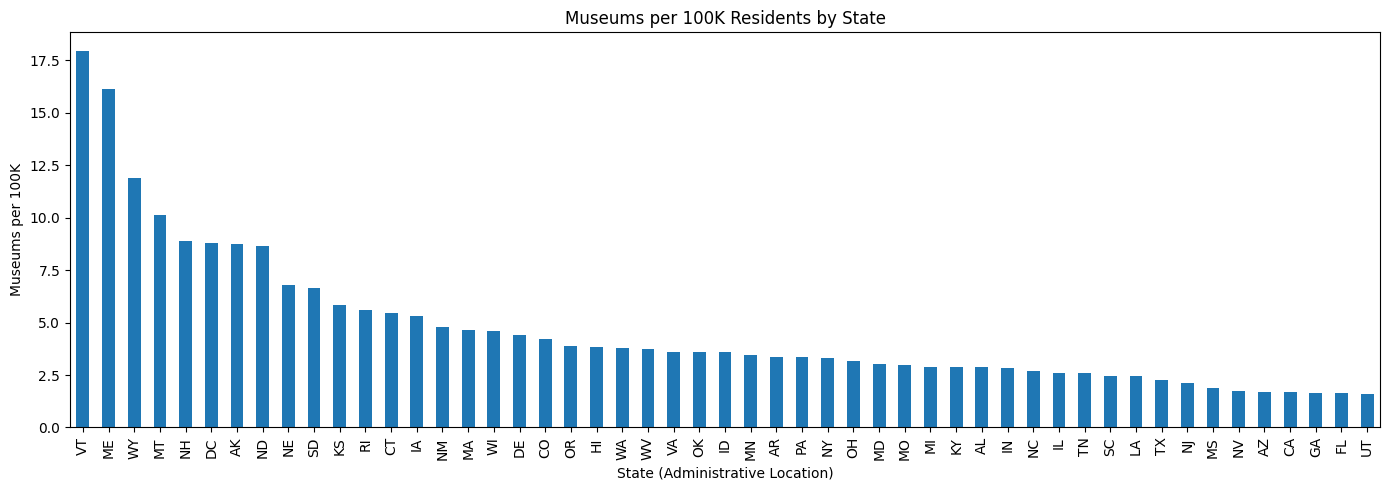

In [32]:
# Museums per capita by state
pop_df = pd.read_csv('state_pop_data.csv', thousands=',')
state_counts = museum_df['State (Physical Location)'].value_counts().reset_index()
state_counts.columns = ['State (Administrative Location)', 'Count']
merged = state_counts.merge(pop_df, on='State (Administrative Location)')
merged['Per 100K'] = merged['Count'] / merged['Population (2008)'] * 100_000
merged = merged.sort_values('Per 100K', ascending=False)

print(f"MOST museums per capita:  {merged.iloc[0]['State (Administrative Location)']} — {merged.iloc[0]['Per 100K']:.1f} per 100K")
print(f"LEAST museums per capita: {merged.iloc[-1]['State (Administrative Location)']} — {merged.iloc[-1]['Per 100K']:.1f} per 100K\n")

merged.plot(x='State (Administrative Location)', y='Per 100K', kind='bar', figsize=(14, 5),
            title='Museums per 100K Residents by State', legend=False)
plt.ylabel('Museums per 100K')
plt.tight_layout()
plt.show()

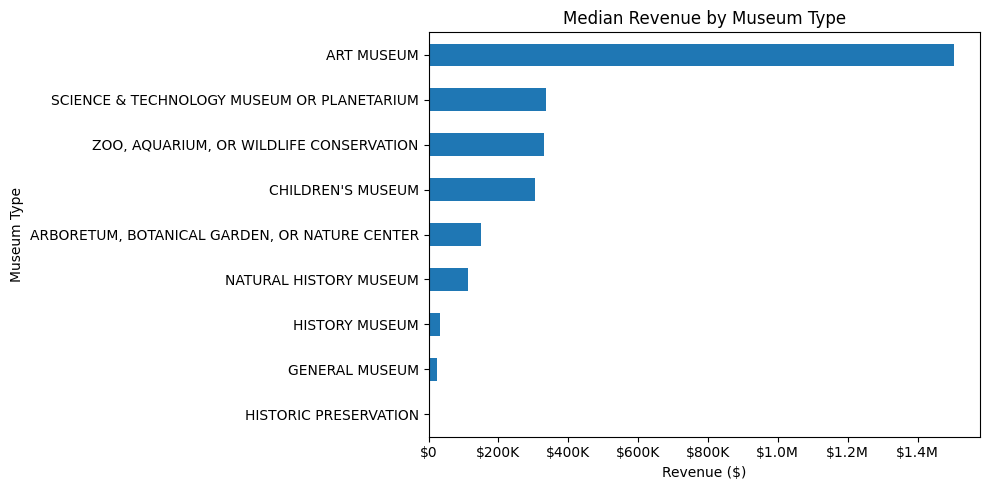

In [31]:
# Convert Revenue to numeric
from matplotlib.ticker import FuncFormatter

def short_dollar(x, _):
    if x >= 1_000_000:
        return f'${x/1_000_000:.1f}M'
    elif x >= 1_000:
        return f'${x/1_000:.0f}K'
    else:
        return f'${x:.0f}'

museum_df['Revenue'] = pd.to_numeric(museum_df['Revenue'], errors='coerce')
ax = museum_df.groupby('Museum Type')['Revenue'].median().sort_values().plot(kind='barh', figsize=(10, 5), title='Median Revenue by Museum Type')
ax.xaxis.set_major_formatter(FuncFormatter(short_dollar))
plt.xlabel('Revenue ($)')
plt.tight_layout()
plt.show()

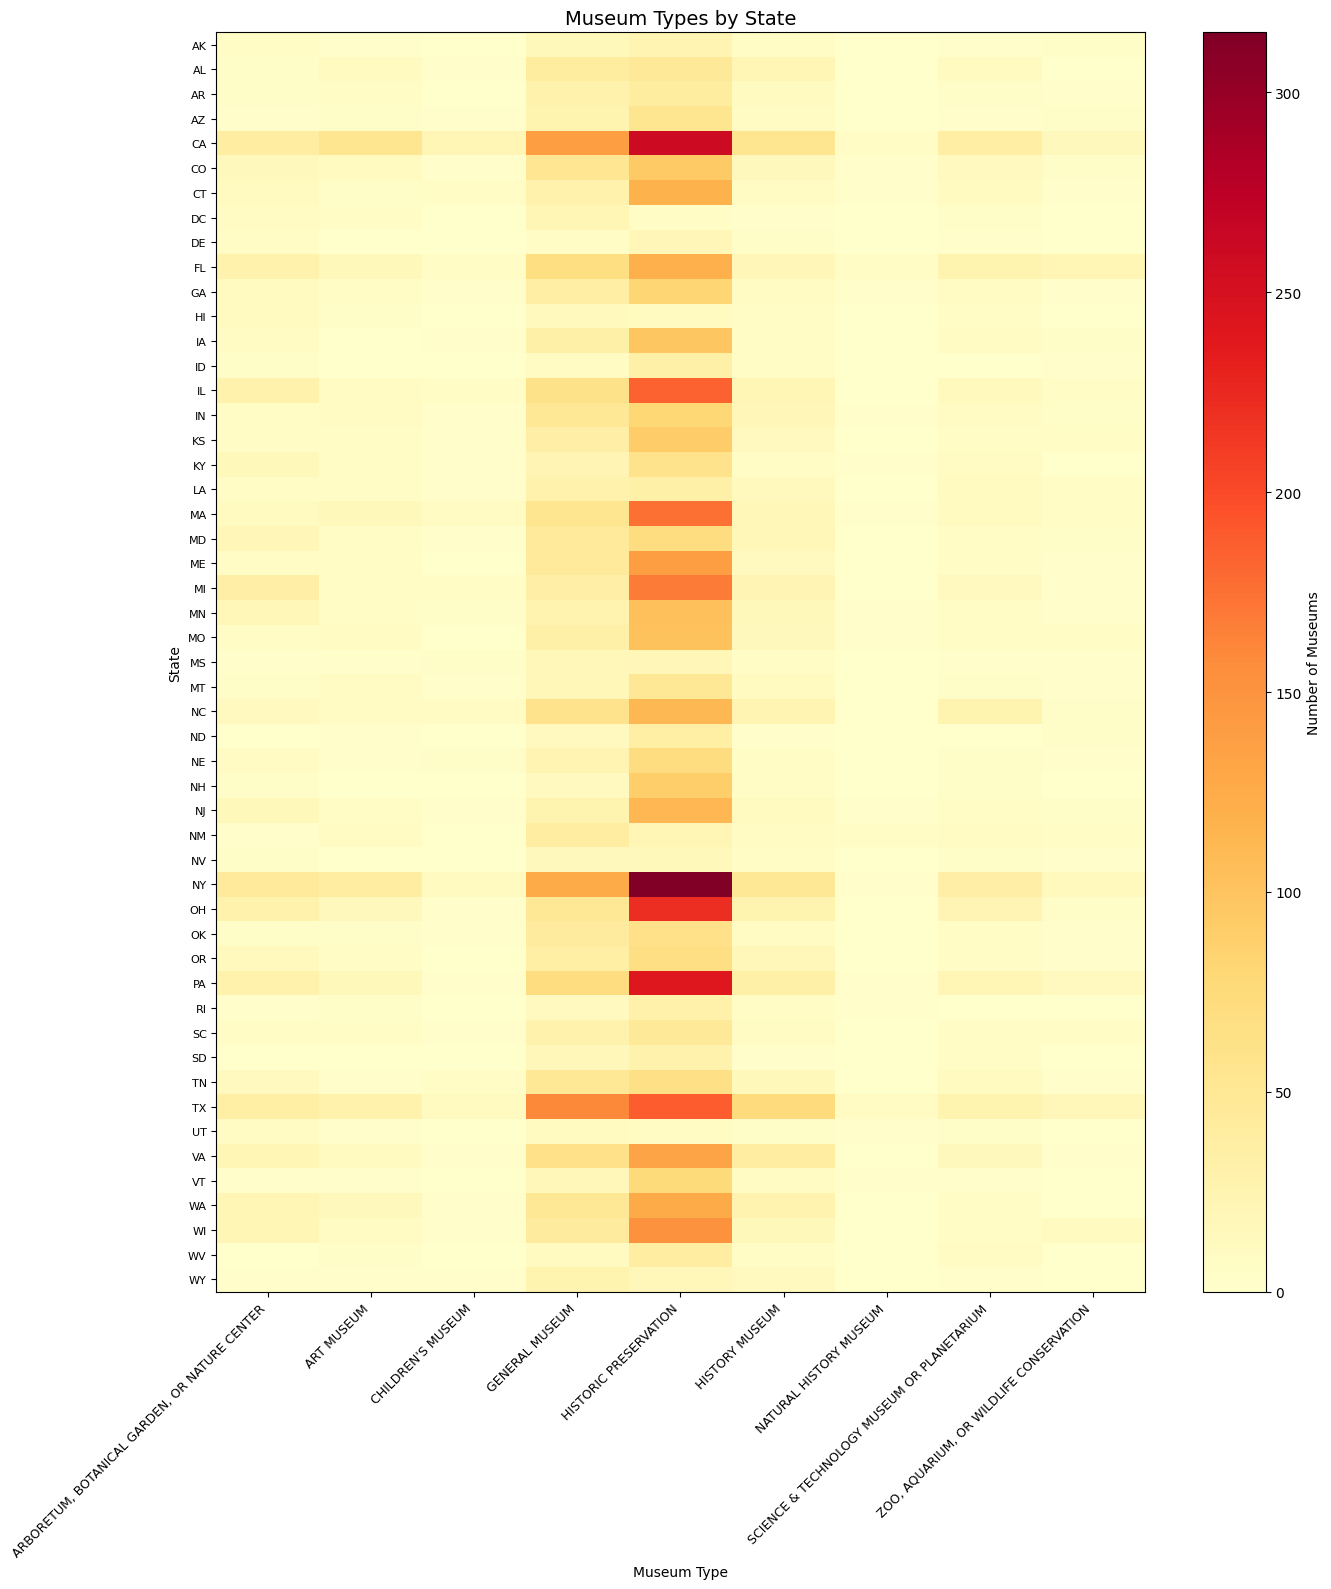

In [16]:
# Museum types by state (heatmap)
type_by_state = museum_df.groupby(['State (Physical Location)', 'Museum Type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 16))
im = ax.imshow(type_by_state.values, aspect='auto', cmap='YlOrRd')

ax.set_xticks(range(len(type_by_state.columns)))
ax.set_xticklabels(type_by_state.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(type_by_state.index)))
ax.set_yticklabels(type_by_state.index, fontsize=8)

plt.colorbar(im, ax=ax, label='Number of Museums')
ax.set_title('Museum Types by State', fontsize=14)
ax.set_xlabel('Museum Type')
ax.set_ylabel('State')
plt.tight_layout()
plt.show()

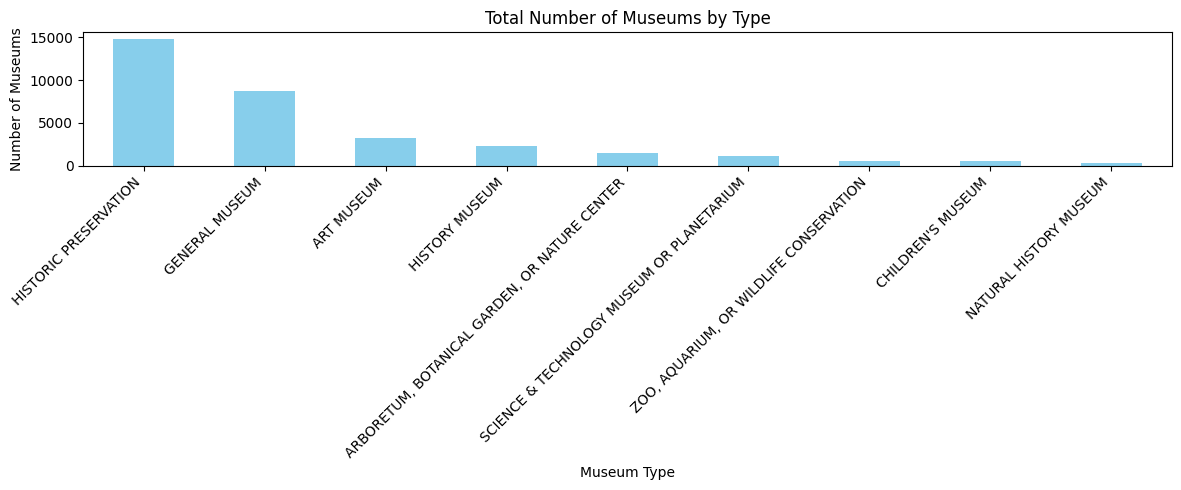

In [35]:
# Total count of each museum type
museum_type_counts = museum_df['Museum Type'].value_counts().sort_values(ascending=False)
museum_type_counts.plot(kind='bar', figsize=(12, 5), color='skyblue', title='Total Number of Museums by Type')
plt.ylabel('Number of Museums')
plt.xlabel('Museum Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

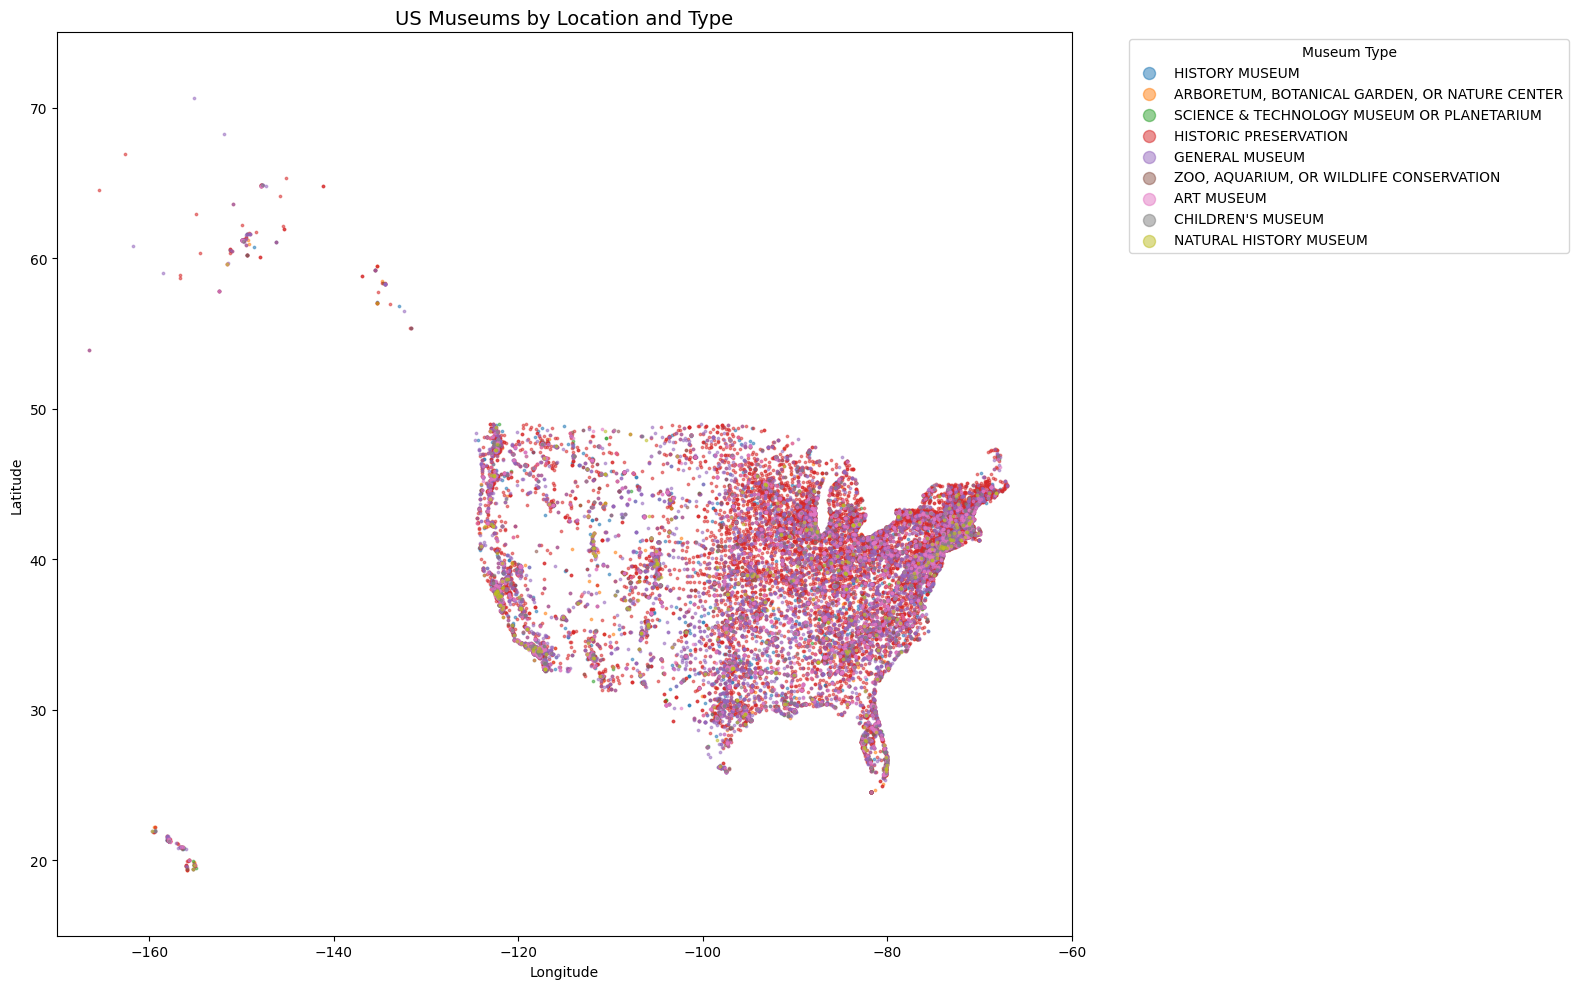

In [17]:
# Geographic scatter plot — US map drawn from museum locations
museum_geo = museum_df.dropna(subset=['Latitude', 'Longitude']).copy()
museum_geo['Latitude'] = pd.to_numeric(museum_geo['Latitude'], errors='coerce')
museum_geo['Longitude'] = pd.to_numeric(museum_geo['Longitude'], errors='coerce')
museum_geo = museum_geo.dropna(subset=['Latitude', 'Longitude'])

fig, ax = plt.subplots(figsize=(16, 10))
types = museum_geo['Museum Type'].unique()
colors = plt.cm.tab10.colors

for i, mtype in enumerate(types):
    subset = museum_geo[museum_geo['Museum Type'] == mtype]
    ax.scatter(subset['Longitude'], subset['Latitude'],
               s=3, alpha=0.5, label=mtype, color=colors[i % len(colors)])

ax.set_title('US Museums by Location and Type', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(title='Museum Type', markerscale=5, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlim(-170, -60)
ax.set_ylim(15, 75)
plt.tight_layout()
plt.show()

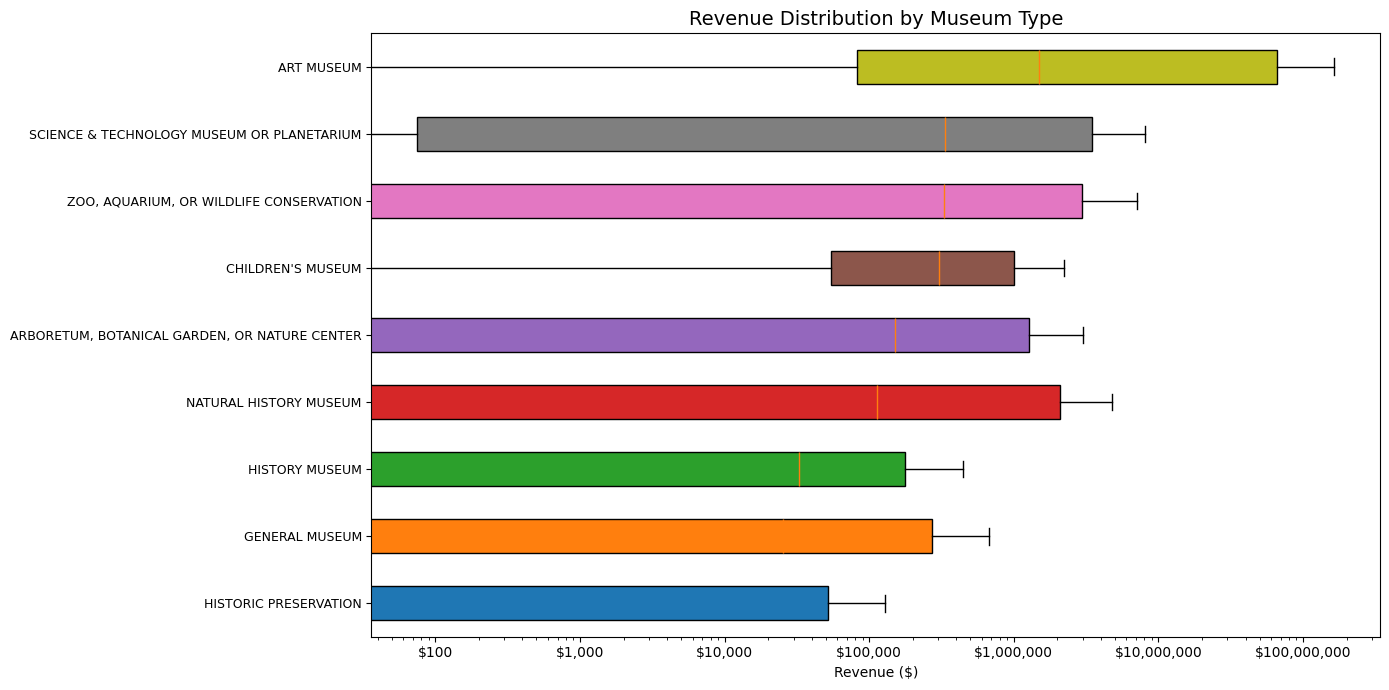

In [28]:
# Revenue Distribution by Museum Type (Box Plot)
import numpy as np
from matplotlib.ticker import FuncFormatter

rev_data = museum_df[['Museum Type', 'Revenue']].dropna()

fig, ax = plt.subplots(figsize=(14, 7))
types = rev_data.groupby('Museum Type')['Revenue'].median().sort_values().index
box_data = [rev_data[rev_data['Museum Type'] == t]['Revenue'].values for t in types]

bp = ax.boxplot(box_data, vert=False, patch_artist=True, showfliers=False)
colors = plt.cm.tab10.colors
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(colors[i % len(colors)])

ax.set_yticklabels(types, fontsize=9)
ax.set_xlabel('Revenue ($)')
ax.set_title('Revenue Distribution by Museum Type', fontsize=14)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

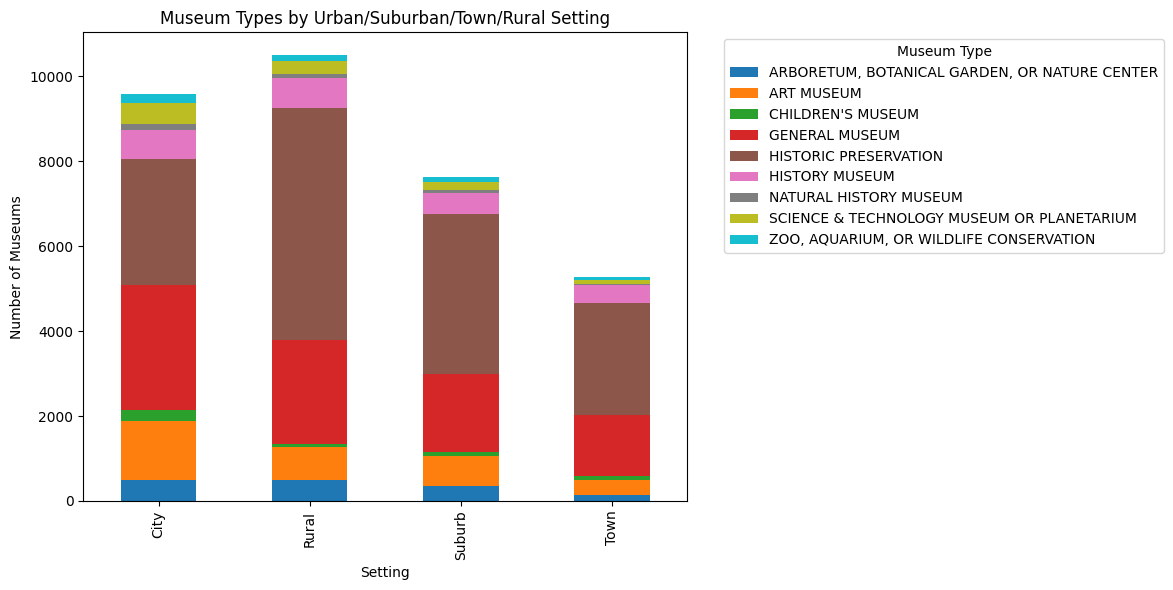

In [25]:
# Urban vs Rural Museum Distribution
# NCES Locale Codes: 1x=City, 2x=Suburb, 3x=Town, 4x=Rural
locale_prefix_map = {'1': 'City', '2': 'Suburb', '3': 'Town', '4': 'Rural'}

locale_codes = museum_df['Locale Code (NCES)'].dropna().astype(str).str.strip()
locale_first = locale_codes.str[0]
museum_df['Locale'] = locale_first.map(locale_prefix_map)

locale_data = museum_df.dropna(subset=['Locale'])
locale_type = locale_data.groupby(['Locale', 'Museum Type']).size().unstack(fill_value=0)

locale_type.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10',
                 title='Museum Types by Urban/Suburban/Town/Rural Setting')
plt.ylabel('Number of Museums')
plt.xlabel('Setting')
plt.legend(title='Museum Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

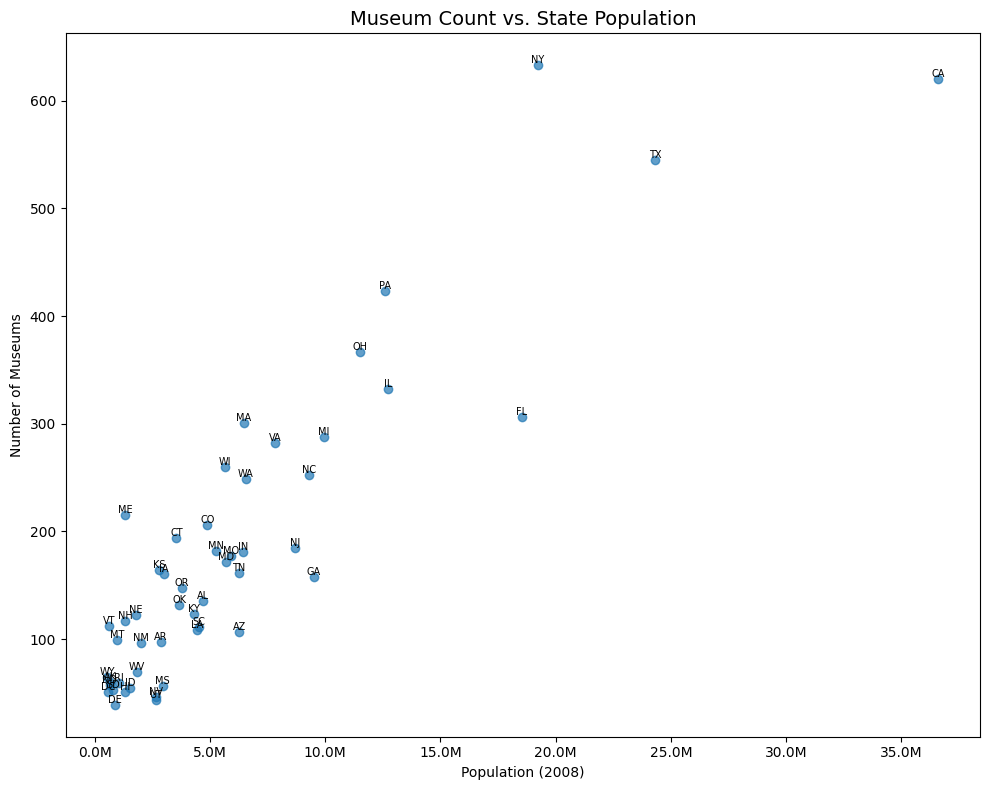

In [34]:
# Museum count vs. population scatter
#Reuse merged df from cell 4
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(merged['Population (2008)'], merged['Count'], alpha=0.7)

for _, row in merged.iterrows():
    ax.annotate(row['State (Administrative Location)'], (row['Population (2008)'], row['Count']), fontsize=7, ha='center', va='bottom')

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))
ax.set_xlabel('Population (2008)')
ax.set_ylabel('Number of Museums')
ax.set_title('Museum Count vs. State Population', fontsize=14)
plt.tight_layout()
plt.show()